In [624]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [625]:
import matplotlib.font_manager as fm
import matplotlib

font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)

---

In [626]:
df = pd.read_csv('./../../Merge/data/result data/Final DF.csv')
df.columns

Index(['Year', 'Nation', 'Eng_Nation', 'Wc_Rank', 'Wc_Point', 'Q_WR', 'Q_GR',
       'F_Rank', 'F_Point', 'F_Rd', 'F_Pd', 'Avg_Apps', 'Avg_Age',
       'Avg_Famous', 'FS_0', 'FS_1', 'FS_2', 'FS_3', 'FS_4', 'FS_5', 'FS_6',
       'FS_7', 'FS_8', 'FS_9', 'FS_10', 'FS_11', 'FS_12', 'FS_13', 'ATK_INDEX',
       'DEF_INDEX'],
      dtype='object')

1. 선수단의 평균나이와 본선 진출 평균 횟수간의 관계

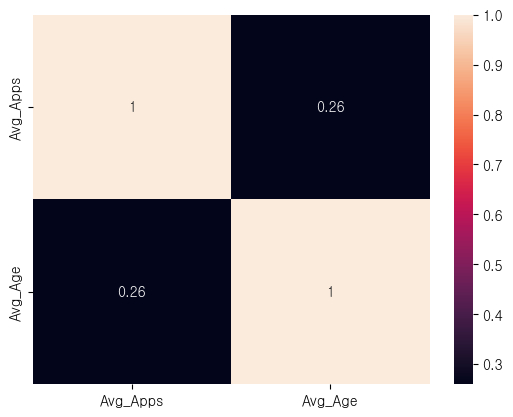

In [627]:
corr_matrix = df[['Avg_Apps', 'Avg_Age']].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [628]:
# 평균 나이 최솟값, 최댓값 확인
df['Avg_Age'].min(), df['Avg_Age'].max()

(np.float64(24.04), np.float64(29.74))

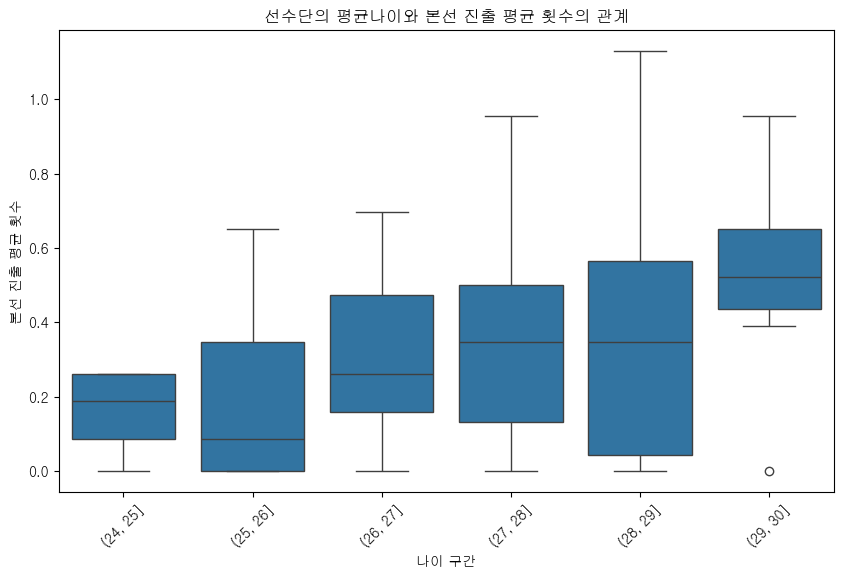

In [629]:
# 나이를 구간으로 나누기
df['Age_Group'] = pd.cut(df['Avg_Age'], bins=range(24, 31, 1))

# 박스플롯 그리기
plt.figure(figsize=(10,6))
sns.boxplot(x='Age_Group', y='Avg_Apps', data=df)
plt.xticks(rotation=45)
plt.title('선수단의 평균나이와 본선 진출 평균 횟수의 관계')
plt.xlabel('나이 구간')
plt.ylabel('본선 진출 평균 횟수')

plt.show()

**분석 결과**

1. 상관관계: 0.26 → 1에 가까운 강한 상관관계라고 보기는 어렵지만, 완전히 무의미한 수준도 아닌 **약한 양(+)의 상관관계**로 해석할 수 있다.
2. 선수단의 평균 나이가 높을수록 그 팀은 과거 월드컵 본선에 더 자주 진출한 경험이 있는 경향이 있다.
    
    나이가 많은 선수들이 포함된 팀일수록 국제 무대에서의 누적 경험치가 높다는 의미로 볼 수 있다. 
    
    본선 무대에 자주 오른 팀은 경험 많은 선수층을 보유하기 쉽다.
    

**가설**

우승팀의 평균나이와 본선 진출 평균 횟수는 모두 높을 것이다.

----

2. 월드컵 우승팀과 비우승팀의 평균나이, 본선 진출 평균 횟수 간 관계

In [630]:
# 정규화
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
df[['Avg_Apps', 'Avg_Age']] = std_scaler.fit_transform(df[['Avg_Apps', 'Avg_Age']])

In [631]:
df_winner = df[df['Wc_Rank']==1] 
df_remain = df.drop(df[df['Wc_Rank']==1].index)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_12660\2319324314.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_winner['팀구분'] = '우승팀'
C:\Users\Playdata\AppData\Local\Temp\ipykernel_12660\2319324314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='팀구분', y='Avg_Age', data=df_compare, palette=['gold','skyblue'])
C:\Users\Playdata\AppData\Local\Temp\ipykernel_12660\2319324314.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='팀구분', y='

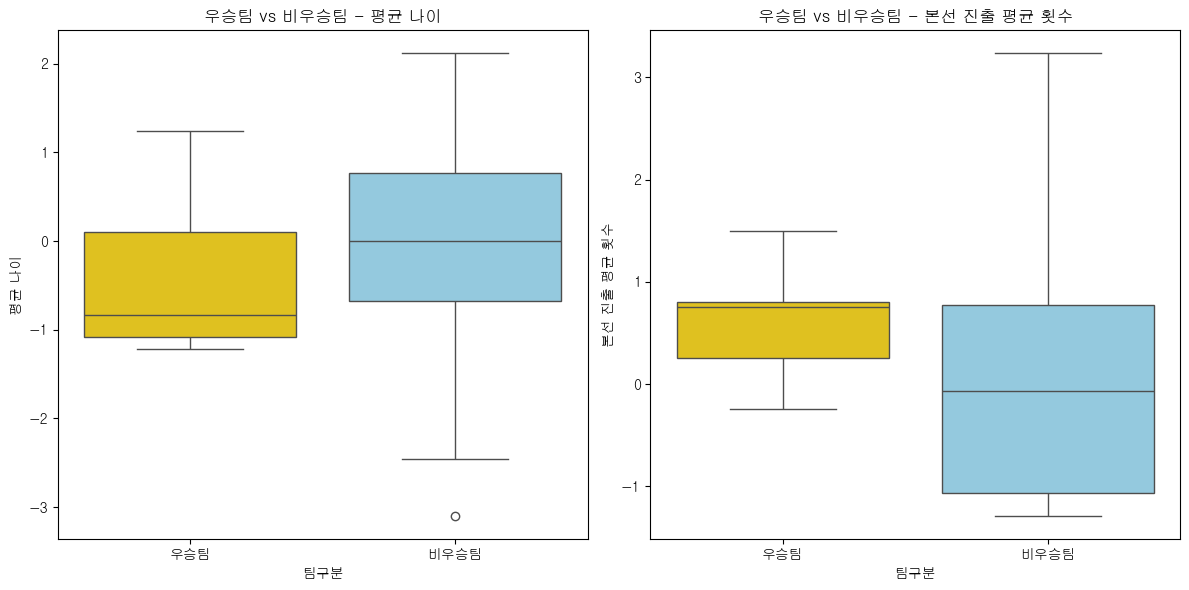

In [632]:
import seaborn as sns

df_winner['팀구분'] = '우승팀'
df_remain['팀구분'] = '비우승팀'
df_compare = pd.concat([df_winner, df_remain])

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.boxplot(x='팀구분', y='Avg_Age', data=df_compare, palette=['gold','skyblue'])
plt.title('우승팀 vs 비우승팀 - 평균 나이')
plt.ylabel('평균 나이')

plt.subplot(1,2,2)
sns.boxplot(x='팀구분', y='Avg_Apps', data=df_compare, palette=['gold','skyblue'])
plt.title('우승팀 vs 비우승팀 - 본선 진출 평균 횟수')
plt.ylabel('본선 진출 평균 횟수')

plt.tight_layout()
plt.show()

**분석 결과**

1. 실제 결과를 비교해보니 우승팀의 평균나이는 낮았지만 본선 진출 평균 횟수는 높았다.
2. 월드컵이 가진 구조적 특성과 연결해보았을 때 본선 진출은 수년간 치러지는 예선전을 통과해야 하므로, 꾸준한 실력과 경험이 매우 중요한 요인으로 작용한다. 즉, 경험 많은 선수들이 다수 포진된 팀이 본선에 도달할 가능성이 크다.
3. 그러나 본선에 진출한 이후의 단판 토너먼트에서는 체력, 경기 집중력, 순간적인 기세 등이 크게 작용하며, 오히려 젊은 선수들의 활약이 우승에 영향을 미친다.

---

3. 월드컵 순위, 평균나이, 본선 진출 평균 횟수 시각화

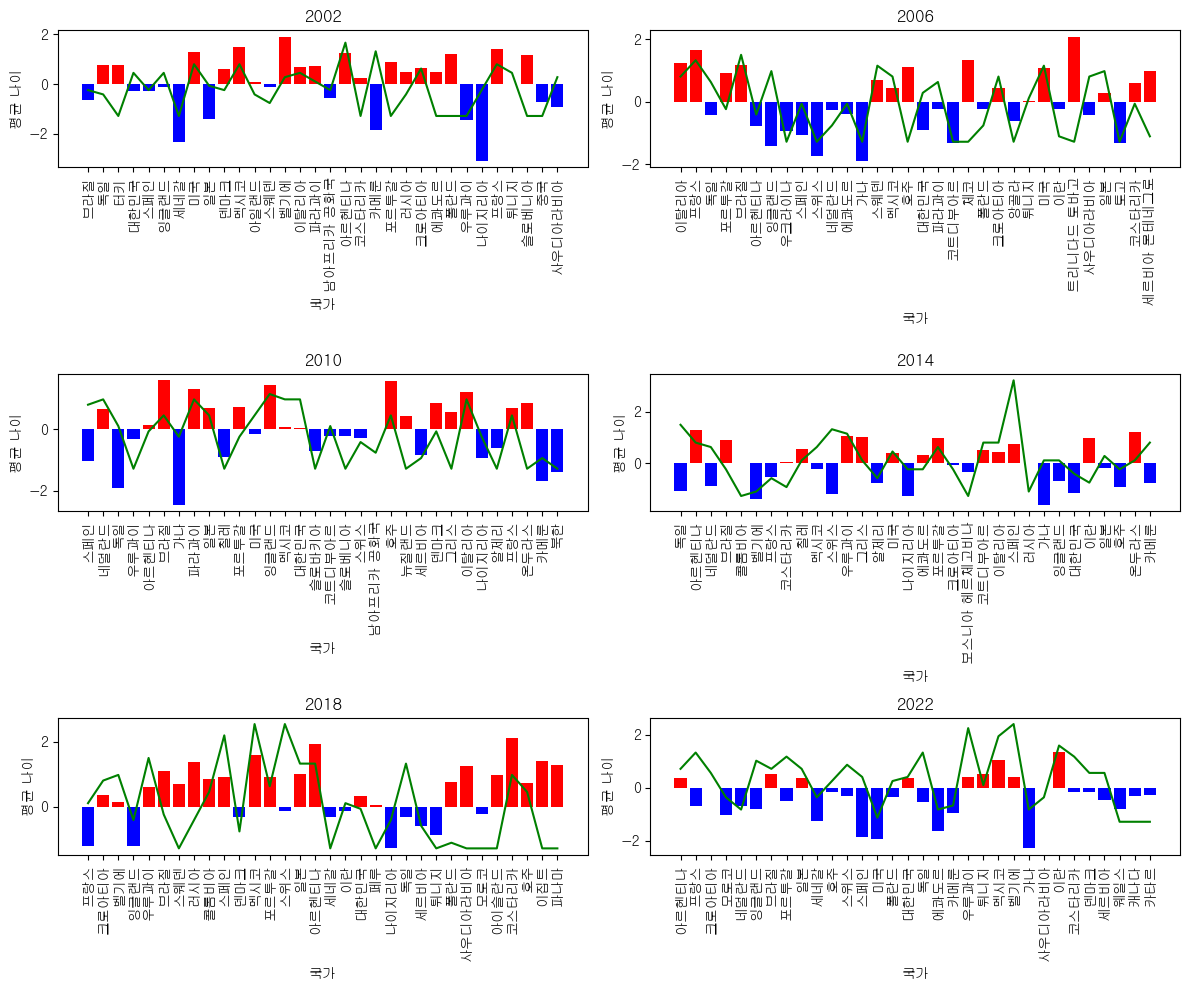

In [633]:
# 국가별 평균나이 시각화
years = sorted(df['Year'].unique())
fig, ax = plt.subplots(3, 2, figsize=(12, 10))

for i, year in enumerate(years):
    row = i // 2
    col = i % 2

    df_year = df[df['Year'] == year]

    colors = ['blue' if val <= 0 else 'red' for val in df_year['Avg_Age']]

    ax[row, col].bar(df_year['Nation'], df_year['Avg_Age'], color=colors)
    ax[row, col].plot(df_year['Nation'], df_year['Avg_Apps'], color='green')
    ax[row, col].set_title(f'{year}')
    ax[row, col].set_xlabel('국가')
    ax[row, col].set_ylabel('평균 나이')
    ax[row, col].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**분석 결과**

1. 선수단의 평균 나이가 높을수록 본선 진출 평균 횟수가 높다.
2. 우승팀은 대체로 평균 나이가 낮다.
3. 년도 별로 분석해보았을 때, 2018년은 대체적으로 평균 나이가 높지만 2022년에는 평균 나이가 낮아지는 경향을 보인다.
4. 현대 축구가 점점 더 빠른 템포와 체력을 요구하면서 젊은 선수들의 비중이 높아지는 것을 보여준다.

**가설**

1. 2018년에 출전했던 나이가 많은 선수들이 4년 후인 2022년 대회에는 참여하지 않았을 가능성이 크다.
2. 2022년 대회에서는 새로운 세대의 젊은 선수들이 다수 투입되면서 팀 전체 평균 나이가 낮아졌을 것이다.

---

4. 2018년 신규, 2022년 은퇴 선수 나이 분포 

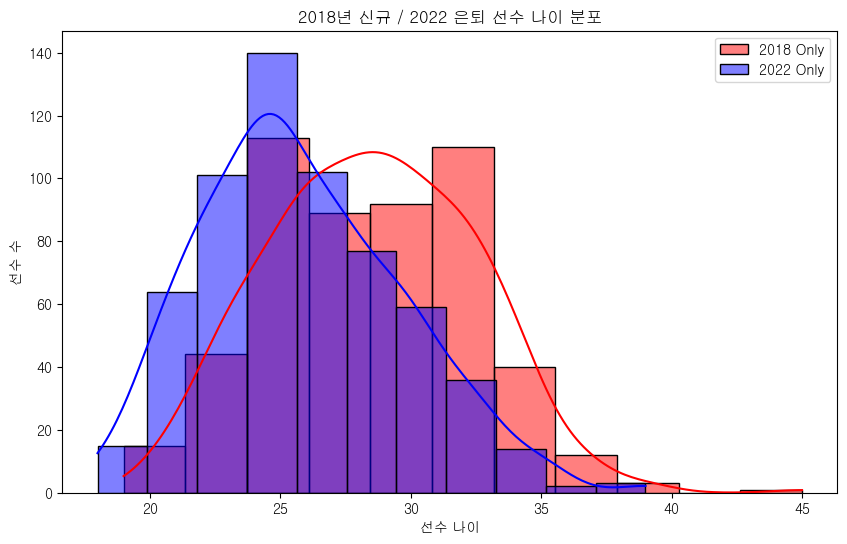

In [634]:
df_players = pd.read_csv('../data/source data/worldcup_players.csv')
df_players['나이'] = df_players['년도'] - df_players['생년월일'].str[:4].astype(int)

# 2018년, 2022년 데이터 분리
df_2018 = df_players[df_players['년도'] == 2018]
df_2022 = df_players[df_players['년도'] == 2022]

# 선수 이름(한글 성명 기준) 리스트
players_2018 = set(df_2018['한글 성명'])
players_2022 = set(df_2022['한글 성명'])

# 2018에는 있지만 2022에는 없는 선수
players_only_2018 = players_2018 - players_2022
players_only_2022 = players_2022 - players_2018

# 결과 출력
df_only_2018 = df_2018[df_2018['한글 성명'].isin(players_only_2018)]
df_only_2022 = df_2022[df_2022['한글 성명'].isin(players_only_2022)]

plt.figure(figsize=(10,6))

sns.histplot(df_only_2018['나이'], color='red', label='2018 Only', kde=True, bins=11)
sns.histplot(df_only_2022['나이'], color='blue', label='2022 Only', kde=True, bins=11)

plt.xlabel('선수 나이')
plt.ylabel('선수 수')
plt.title('2018년 신규 / 2022 은퇴 선수 나이 분포')
plt.legend()
plt.show()

**분석 결과**

예상대로 2018년도에 나이가 많은 선수들이 은퇴하고 2022년에 젊은 선수가 다수 투입되었다.

---

**결론**

1. 본선 진출은 나이와 경험이 많은 팀이 유리하다. (평균 나이 ↑, 본선 경험 ↑)
2. 그러나 우승은 젊은 선수들의 활약이 중요하다. (평균 나이 ↓, 본선 경험 ↑)
3. 실제 데이터에서도 2018년과 2022년을 비교했을 때, 세대교체 현상이 뚜렷하게 나타났으며, 축구라는 스포츠가 점점 더 빠르고 강도 높은 경기로 변하고 있다.